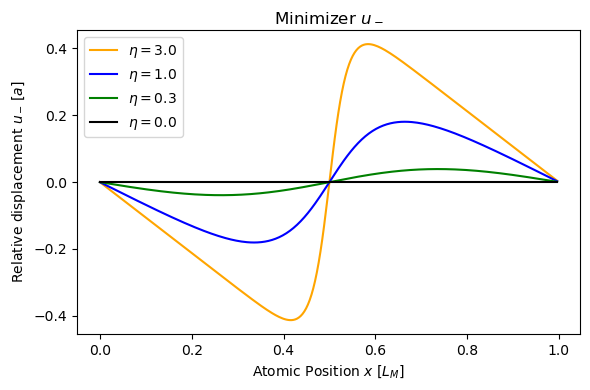

In [ ]:
import numpy as np

def solve_u(eta, N=512, alpha=1.0, dealias=None, tol=1e-10, max_iter=10000):
    """
    Solve -1/eta^2 U''(X) + 4π√2 sin(2π(X + √2 U)) = 0 
    with periodic boundary and ∫_0^1 U dX = 0.
    Returns array U(X) of length N.
    """
    # Set up grid and initial guess
    X = np.linspace(0, 1, N, endpoint=False)
    U = np.zeros(N)  # start with U=0 (satisfies mean 0)
    if eta == 0:  # trivial case: U ≡ 0
        return U
    
    # Precompute constant factor in RHS
    const = 4 * np.pi * np.sqrt(2) * (eta**2)
    
    # Determine padding factor for dealiasing
    pad_factor = 1.0
    if dealias == '2/3':
        pad_factor = 1.5   # 3/2 rule: pad by 1.5× (zero out upper 1/3 of modes)
    elif dealias == '1/2':
        pad_factor = 2.0   # 1/2 rule: pad by 2× (zero out upper 1/2 of modes)
    
    # Helper: compute U_new from U_old by solving U_new'' = const * sin(2π(X + √2 U_old))
    def compute_update(U_old):
        # Optionally pad to a larger grid for dealiasing
        if pad_factor > 1.0:
            M = int(np.round(pad_factor * N))
            if M % 2 == 1:  # ensure even length for simpler FFT symmetry
                M += 1
            # FFT of U_old, pad in spectral domain
            U_old_fft = np.fft.rfft(U_old)
            U_old_fft_pad = np.zeros(M//2 + 1, dtype=complex)
            old_half = len(U_old_fft)
            U_old_fft_pad[:old_half] = U_old_fft[:old_half]
            # Inverse FFT to get U on the larger grid
            U_pad = np.fft.irfft(U_old_fft_pad, n=M)
            X_pad = np.linspace(0, 1, M, endpoint=False)
            # Compute nonlinear term on padded grid
            f_pad = const * np.sin(2 * np.pi * (X_pad + np.sqrt(2) * U_pad))
            f_pad -= f_pad.mean()  # enforce zero mean
            # Transform back and truncate high frequencies
            f_pad_fft = np.fft.rfft(f_pad)
            f_trunc_fft = np.zeros(old_half, dtype=complex)
            f_trunc_fft[:old_half] = f_pad_fft[:old_half]  # keep lowest modes
            # Solve in spectral domain for U_new (second derivative inversion)
            U_new_fft = np.zeros_like(f_trunc_fft)
            U_new_fft[0] = 0  # zero mean
            # Handle Nyquist mode if N even
            if N % 2 == 0:
                k_nyq = N//2
                U_new_fft[k_nyq] = -f_trunc_fft[k_nyq] / ((2*np.pi*k_nyq)**2)
                # modes 1..N/2-1
                for k in range(1, k_nyq):
                    U_new_fft[k] = -f_trunc_fft[k] / ((2*np.pi*k)**2)
            else:
                # if N is odd, len(f_trunc_fft)=floor(N/2)+1 (no Nyquist mode)
                for k in range(1, len(f_trunc_fft)):
                    U_new_fft[k] = -f_trunc_fft[k] / ((2*np.pi*k)**2)
            # Inverse FFT back to physical space (length N)
            U_new = np.fft.irfft(U_new_fft, n=N)
        else:
            # No dealiasing: compute on original grid
            f = const * np.sin(2 * np.pi * (X + np.sqrt(2) * U_old))
            f -= f.mean()  # enforce mean 0 so that U'' = f is solvable
            # Solve U_new'' = f via spectral division
            f_fft = np.fft.rfft(f)
            U_new_fft = np.zeros_like(f_fft)
            U_new_fft[0] = 0.0  # zero mean mode
            if N % 2 == 0: 
                k_nyq = N//2
                U_new_fft[k_nyq] = -f_fft[k_nyq] / ((2*np.pi*k_nyq)**2)
                for k in range(1, k_nyq):
                    U_new_fft[k] = -f_fft[k] / ((2*np.pi*k)**2)
            else:
                for k in range(1, len(f_fft)):  # up to floor(N/2)
                    U_new_fft[k] = -f_fft[k] / ((2*np.pi*k)**2)
            U_new = np.fft.irfft(U_new_fft, n=N)
        # Enforce mean-zero (should already hold by construction)
        U_new -= U_new.mean()
        return U_new
    
    # Iterative nonlinear solve
    for it in range(max_iter):
        U_candidate = compute_update(U)
        # Mix old and new (relaxation)
        U_next = (1 - alpha) * U + alpha * U_candidate
        # Check convergence: use change in solution as criterion
        if np.linalg.norm(U_next - U) < tol:
            U = U_next
            break
        U = U_next
    return U

# Example usage: compute solutions for eta=0, 0.3, 1, 3
etas = [0, 0.3, 1.0, 3.0]
solutions = {}
for eta in etas:
    # Use smaller α for larger η to ensure convergence
    alpha = 1.0 if eta < 1.0 else (0.2 if eta == 1.0 else 0.05)
    method = 'none' if eta < 3.0 else '2/3'   # apply dealiasing for the toughest case η=3
    solutions[eta] = solve_u(eta, N=256, alpha=alpha, dealias=method)

# Plot the solutions
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
for eta, color in zip([3.0, 1.0, 0.3, 0.0], ['orange','blue','green','black']):
    U = solutions[eta]; X = np.linspace(0,1,len(U), endpoint=False)
    plt.plot(X, U, color=color, label=f'$\\eta = {eta}$')
plt.title("Minimizer $u_-$")
plt.xlabel("Atomic Position $x$ [$L_M$]")
plt.ylabel("Relative displacement $u_-\\,[a]$")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
